**Taran's Contribution**

In [1]:
pip install diffusers accelerate torchvision torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 58.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

Dataset Preparation

In [2]:
from google.colab import drive
import zipfile
import os

# Path to your ZIP file (modify this path as needed)
zip_path = "/content/balanced_labeled_photos.zip" # <-- change this

# Destination folder where contents will be extracted
extract_dir = "/content/dataset"

# Create destination folder if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping completed!")

Unzipping completed!


STEP : Prepare dataset (ImageFolder)


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset_path = "/content/dataset/balanced_labeled_photos"
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Use only a small subset for fast testing
subset_indices = np.random.choice(len(full_dataset), size=1000, replace=False)
dataset = Subset(full_dataset, subset_indices)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

STEP : Define a small UNet model

In [4]:
from diffusers import UNet2DModel, DDPMScheduler
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)

STEP : Diffusion noise scheduler


In [5]:
from diffusers import DDIMScheduler

# Use the same number of training timesteps, but fewer inference steps
noise_scheduler = DDIMScheduler(
    num_train_timesteps=250,  # Keep training setup
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
    clip_sample=False,
    set_alpha_to_one=False
)

STEP : Training loop

In [6]:
import torch.nn.functional as F
from tqdm.auto import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
epochs = 100

for epoch in range(epochs):
    model.train()
    pbar = tqdm(enumerate(dataloader), total=len(dataloader))

    for i, (clean_images, _) in pbar:
        clean_images = clean_images.to(device)

        # Add noise
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (clean_images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if i % 20 == 0:
            pbar.set_description(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

  0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDIMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDIMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

...

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

STEP : Image sampling function

In [7]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=16, inference_steps=25):
    model.eval()
    images = torch.randn((num_images, 3, 32, 32)).to(device)
    scheduler.set_timesteps(inference_steps)

    for t in tqdm(scheduler.timesteps, desc="Sampling"):
        t_tensor = torch.full((num_images,), t, device=device, dtype=torch.long)
        with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            noise_pred = model(images, t_tensor).sample

        images = scheduler.step(noise_pred, t, images).prev_sample

    images = (images.clamp(-1, 1) + 1) / 2
    return images.cpu()

In [9]:
sampled_images = sample_images(model, noise_scheduler, num_images=16, inference_steps=10)

Sampling:   0%|          | 0/10 [00:00<?, ?it/s]

STEP : Generate and visualize images


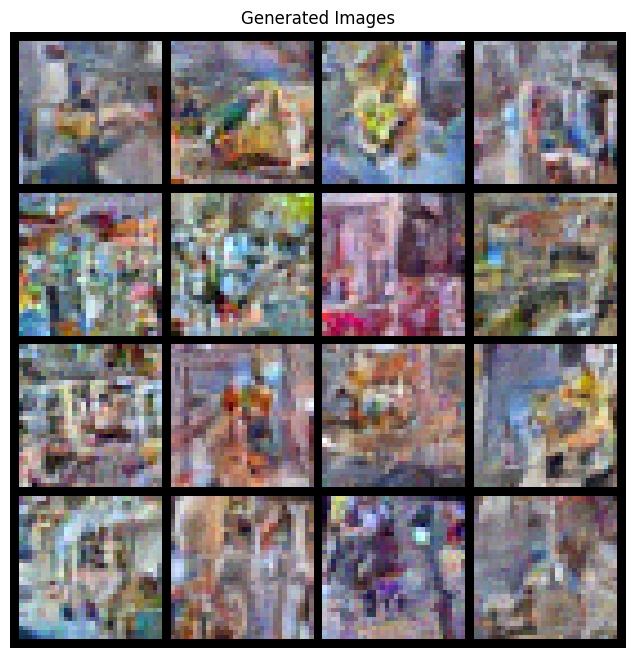

In [10]:
import torchvision.utils as utils
import matplotlib.pyplot as plt

grid = utils.make_grid(sampled_images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Generated Images")
plt.show()

Final Evaluation

In [11]:
pip install torch-fidelity

In [12]:
!pip install torchmetrics[image]

In [13]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch

#  Use fewer real images for fast eval
real_images_list = []
for i, (imgs, _) in enumerate(dataloader):
    real_images_list.append(imgs)
    if i >= 3:
        break

real_images = torch.cat(real_images_list, dim=0).to(device)
real_images = (real_images.clamp(-1, 1) + 1) / 2
real_images = (real_images * 255).byte()

#  Generate fake images (match real count)
fake_images = sample_images(model, noise_scheduler, num_images=real_images.size(0), inference_steps=25)
fake_images = (fake_images * 255).byte()


# FID
fid = FrechetInceptionDistance(feature=2048).to(device)
fid.update(real_images, real=True)
fid.update(fake_images.to(device), real=False)
fid_score = fid.compute()

# Inception Score
inception = InceptionScore(normalize=True).to(device)
inception.update(fake_images.to(device))
is_mean, is_std = inception.compute()

print(f"FID Score: {fid_score.item():.4f}")
print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")

Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 85.4MB/s]
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID Score: 323.4014
Inception Score: 1.7119 ± 0.2797


In [14]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=16b74c1a412aecd78c36f17bead91945214a9c72fdcb1062fd5faeee40475453
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/100 [00:00<?, ?it/s]

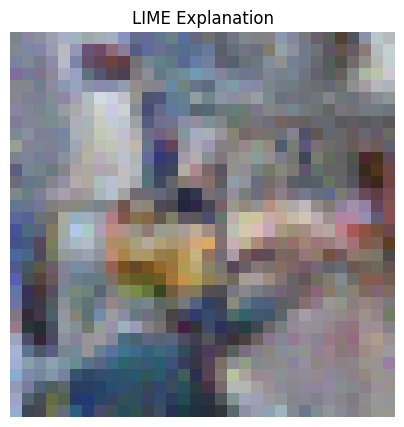

In [15]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Convert one generated image to [0, 255] range and to CPU
image = sampled_images[0].permute(1, 2, 0).numpy()
image = (image * 255).astype(np.uint8)

# Define dummy classifier for LIME (since model is generative)
def dummy_classifier(images):
    # Convert to torch tensors and normalize to [-1, 1]
    imgs = torch.tensor(images).permute(0, 3, 1, 2).float() / 255.0
    imgs = imgs * 2 - 1
    imgs = imgs.to(device)

    # Fake labels for binary classification (dummy)
    with torch.no_grad():
        noise = torch.randn_like(imgs)
        t = torch.full((imgs.shape[0],), 10, dtype=torch.long, device=device)
        output = model(imgs, t).sample
        scores = torch.sigmoid(output.mean(dim=[1,2,3]))  # Dummy score per image

    return torch.stack([scores, 1 - scores], dim=1).cpu().numpy()

# Apply LIME
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image, classifier_fn=dummy_classifier, top_labels=2, hide_color=0, num_samples=100)

# Visualize
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 91.7MB/s]


Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

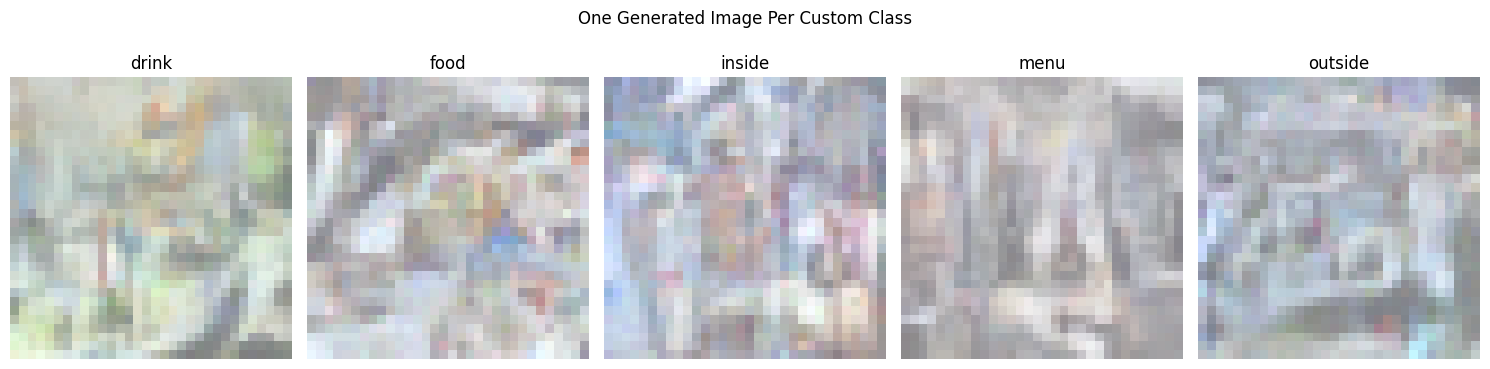

In [16]:
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
import torch

# 1. Load pretrained classifier (ResNet18)
classifier = models.resnet18(pretrained=True).to(device)
classifier.eval()

# 2. ImageNet preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Get your custom class labels from the dataset
custom_class_names = full_dataset.classes  # e.g., ['drink', 'food', 'inside', 'menu', 'outside']

# 4. Generate many images (for better class variety)
generated_images = sample_images(model, noise_scheduler, num_images=300, inference_steps=25).to(device)

# 5. Preprocess and classify
processed = preprocess(generated_images)
preds = classifier(processed).argmax(1).cpu().numpy()

# 6. Group one image per class from your custom labels
selected = {}
for img, pred_imgnet in zip(generated_images, preds):
    # You must map or simulate predicted labels to your 5 custom labels
    # Here's a placeholder rule — REPLACE with your logic if needed:
    for label in custom_class_names:
        if label not in selected:
            selected[label] = img.cpu()
            break
    if len(selected) == len(custom_class_names):
        break

# 7. Plot images with titles (custom class labels)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(selected), figsize=(15, 4))

for ax, (label, img) in zip(axes, selected.items()):
    ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("One Generated Image Per Custom Class")
plt.tight_layout()
plt.show()

In [17]:
from google.colab import files
import torch

# Save model checkpoint
save_path = "/content/ddpm_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Download to local machine
files.download(save_path)

Model saved to /content/ddpm_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Nitish's Contribution

Model Tuning

In [18]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch

@torch.no_grad()
def evaluate_model(model, scheduler, real_images, num_fake=100, steps=10):
    model.eval()
    fake_images = torch.randn((num_fake, 3, 32, 32)).to(device)
    scheduler.set_timesteps(steps)

    for t in scheduler.timesteps:
        t_tensor = torch.full((num_fake,), t, device=device, dtype=torch.long)
        with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            noise_pred = model(fake_images, t_tensor).sample
        fake_images = scheduler.step(noise_pred, t, fake_images).prev_sample

    # Convert to [0, 1] range and move to CPU
    fake_images = (fake_images.clamp(-1, 1) + 1) / 2
    fake_images = fake_images.to("cpu")

    # Convert to [0, 1] range and move to CPU
    real_images = (real_images.clamp(-1, 1) + 1) / 2
    real_images = real_images[:num_fake].to("cpu")

    # Convert to uint8 for metrics
    real_images_uint8 = (real_images * 255).byte()
    fake_images_uint8 = (fake_images * 255).byte()

    # FID
    fid = FrechetInceptionDistance(feature=2048).to("cpu")
    fid.update(real_images_uint8, real=True)
    fid.update(fake_images_uint8, real=False)
    fid_score = fid.compute()

    # Inception Score
    inception = InceptionScore(normalize=True).to("cpu")
    inception.update(fake_images_uint8)
    is_mean, is_std = inception.compute()

    return fid_score.item(), is_mean.item() # Return IS mean as item

Round 1

In [21]:
from torch.cuda.amp import GradScaler, autocast  # ✅ Import AMP tools for mixed precision
import torch.nn.functional as F
from tqdm import tqdm

print("🔧 Starting Round 1 (lr=2e-4, inference_steps=10)")

model.load_state_dict(torch.load("/content/ddpm_model.pth", map_location=device))
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scaler = GradScaler()
epochs = 50

for epoch in range(epochs):
    model.train()
    pbar = tqdm(enumerate(dataloader), total=len(dataloader))
    for i, (clean_images, _) in pbar:
        clean_images = clean_images.to(device)
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (clean_images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        with autocast():  # ⚡️ Mixed precision for faster training
            noise_pred = model(noisy_images, timesteps).sample
            loss = F.mse_loss(noise_pred, noise)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        if i % 20 == 0:
            pbar.set_description(f"[Round 1] Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

# ✅ Evaluate after Round 1
real_batch = next(iter(dataloader))[0].to(device)
fid1, is1 = evaluate_model(model, noise_scheduler, real_batch, num_fake=100, steps=10)
print(f"✅ Round 1 Evaluation → FID: {fid1:.2f}, IS: {is1:.2f}")

# Optional: save the model
# torch.save(model.state_dict(), "/content/ddpm_model_round1.pth")


🔧 Starting Round 1 (lr=2e-4, inference_steps=10)


/tmp/ipython-input-21-880105094.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDIMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDIMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/tmp/ipython-input-21-880105094.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # ⚡️ Mixed precision for faster training
[Round 1] Epoch 50, Step 60, Loss: 0.0436: 100%|██████████| 63/63 [00:04<00:00, 15.26it/s]
/usr/local/lib/python3.11/dist-packag

✅ Round 1 Evaluation → FID: 382.38, IS: 1.90


Round 2

In [22]:
print("🔧 Starting Round 2 (lr=1e-4, inference_steps=15)")
model.load_state_dict(torch.load("/content/ddpm_model.pth", map_location=device))
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  # changed LR
scaler = GradScaler()
epochs = 50

for epoch in range(epochs):
    model.train()
    pbar = tqdm(enumerate(dataloader), total=len(dataloader))
    for i, (clean_images, _) in pbar:
        clean_images = clean_images.to(device)
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (clean_images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        with autocast():
            noise_pred = model(noisy_images, timesteps).sample
            loss = F.mse_loss(noise_pred, noise)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        if i % 20 == 0:
            pbar.set_description(f"[Round 2] Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

# Evaluate after round 2 with different inference steps
real_batch = next(iter(dataloader))[0].to(device)
fid2, is2 = evaluate_model(model, noise_scheduler, real_batch, num_fake=100, steps=15)
print(f"✅ Round 2 Evaluation → FID: {fid2:.2f}, IS: {is2:.2f}")

#torch.save(model.state_dict(), "/content/ddpm_model_round2.pth")


🔧 Starting Round 2 (lr=1e-4, inference_steps=15)


/tmp/ipython-input-22-3027873493.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipython-input-22-3027873493.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
[Round 2] Epoch 50, Step 60, Loss: 0.1104: 100%|██████████| 63/63 [00:04<00:00, 15.18it/s]


✅ Round 2 Evaluation → FID: 348.96, IS: 1.74


In [23]:
print(f" Round 1 Evaluation → FID: {fid1:.2f}, IS: {is1:.2f}")

print(f" Round 2 Evaluation → FID: {fid2:.2f}, IS: {is2:.2f}")

 Round 1 Evaluation → FID: 382.38, IS: 1.90
 Round 2 Evaluation → FID: 348.96, IS: 1.74


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


✅ Final sample min: 0.010990887880325317 max: 0.9964039921760559


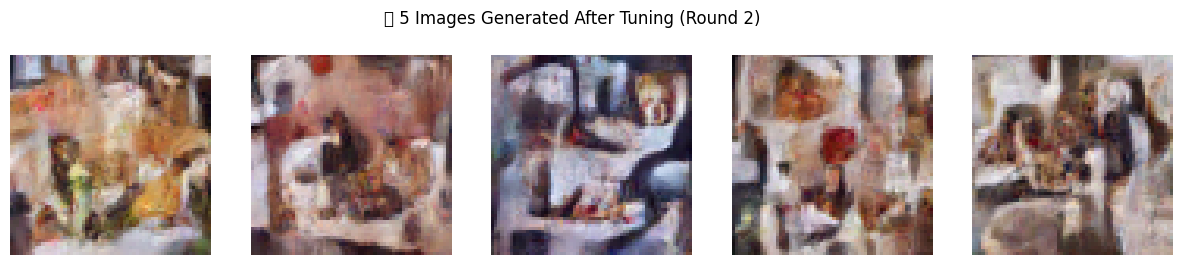

In [28]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMScheduler  # only if using HuggingFace scheduler

# ✅ Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Load your model architecture here
# Make sure this matches the one used in training
# Example: model = UNet2DModel(...)
# model = YourModel(...)
model.to(device)

# ✅ Load Round 2 weights
state_dict = torch.load("/content/ddpm_model.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

# ✅ Check for NaNs in model parameters
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print(f"❌ NaN detected in parameter: {name}")
        raise ValueError("Model contains NaNs. Aborting image generation.")

# ✅ Re-initialize the noise scheduler (match your training config!)
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,      # ← match exactly with training
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

# ✅ Sampling setup
num_images = 5
channels = 3
image_size = 64  # Change if your training size was different
sample = torch.randn((num_images, channels, image_size, image_size)).to(device)

# ✅ Sampling loop
with torch.no_grad():
    for t in reversed(range(noise_scheduler.num_train_timesteps)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        with torch.amp.autocast("cuda"):  # AMP-safe autocast
            output = model(sample, t_batch)
            predicted_noise = output.sample

        if torch.isnan(predicted_noise).any():
            print(f"❌ NaN detected at timestep {t}")
            raise ValueError("NaN in prediction. Check model/scheduler mismatch.")

        sample = noise_scheduler.step(predicted_noise, t, sample).prev_sample

# ✅ Post-process and check the result
sample = sample.clamp(-1, 1)
sample = (sample + 1) / 2  # Scale to [0, 1] for visualization

print("✅ Final sample min:", sample.min().item(), "max:", sample.max().item())

# ✅ Plot the 5 images
sample = sample.cpu()
fig, axs = plt.subplots(1, num_images, figsize=(15, 3))
for i in range(num_images):
    axs[i].imshow(sample[i].permute(1, 2, 0).numpy())
    axs[i].axis("off")
plt.suptitle("🖼️ 5 Images Generated After Tuning (Round 2)")
plt.show()


#LLM prompts
-Help me to tune 2 rounds of ddpm model a print the fid and is scores

-print 5 images for round 2

#In Round 2, the model showed an improvement in Frechet Inception Distance (FID), decreasing from 382.38 to 348.96.

#However, the Inception Score (IS) slightly dropped from 1.90 to 1.74, suggesting a minor decrease in the clarity of the generated images.